In [46]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
import pandas as pd
import mysql.connector
# from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Database Connection
db_config = {"host": "localhost", "user": "root", "password": "", "database": "electrical_pos"}
conn = mysql.connector.connect(**db_config)

In [48]:
# query_basket = """
#     SELECT ti.trans_id, p.product_name 
#     FROM transaction_items ti 
#     JOIN products p ON ti.product_id = p.product_id
#     JOIN transactions t ON ti.trans_id = t.trans_id
#     WHERE t.status = 'Completed'
#       AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
# """ 
# df = pd.read_sql(query_basket, conn)

In [49]:
# Database ထဲက အချက်အလက်အစိမ်းတွေကိုပဲ ဆွဲထုတ်မယ်
query_raw = """
    SELECT 
        t.trans_id, 
        p.product_name,
        ti.quantity,
        p.price,
        t.trans_date
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'Completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
"""
df_raw = pd.read_sql(query_raw, conn)

In [50]:
df_raw

,trans_id,product_name,quantity,price,trans_date
0,1,Gang Box,1,1200.0,2025-10-14 20:22:45
1,1,Wire 1.5mm,1,45000.0,2025-10-14 20:22:45
2,1,Wall Switch,1,2500.0,2025-10-14 20:22:45
3,1,Electric Tape,1,1000.0,2025-10-14 20:22:45
4,2,Wire 1.5mm,1,45000.0,2025-08-14 19:44:43
...,...,...,...,...,...
15245,5003,Deep Cycle Battery,3,450000.0,2025-12-22 19:21:54
15246,5003,Solar Controller,1,35000.0,2025-12-22 19:21:54
15247,5004,Electric Kettle,2,28000.0,2025-10-20 19:52:41
15248,5005,Inverter 1000W,1,250000.0,2026-02-08 20:40:44


In [51]:
df_raw.count()

trans_id        15250
product_name    15250
quantity        15250
price           15250
trans_date      15250
dtype: int64

In [52]:
df_raw.describe()

,trans_id,quantity,price,trans_date
count,15250.000000,15250.000000,15250.000000,15250
mean,2515.840590,1.592197,100053.036066,2025-11-10 12:45:09.025573632
min,1.000000,1.000000,1000.000000,2025-08-12 21:46:05
25%,1266.000000,1.000000,4500.000000,2025-09-25 09:42:04.500000
50%,2522.000000,1.000000,35000.000000,2025-11-10 00:15:03
75%,3770.000000,2.000000,125000.000000,2025-12-25 11:32:00.249999872
max,5005.000000,4.000000,480000.000000,2026-02-09 19:05:20
std,1443.498303,0.795953,142181.179164,NaN


In [53]:
# --- ၃.၂ Data Cleaning & Preprocessing (Extended) ---

# ၁။ Check for Missing/Null Values
null_count = df_raw.isnull().sum().sum()
print(f"Initial Null values found: {null_count}")

Initial Null values found: 0


In [54]:

# တကယ်လို့ Null ရှိရင် drop လုပ်မယ် (သို့မဟုတ် zero နဲ့ fill လုပ်မယ်)
df_raw = df_raw.dropna() 

In [55]:

# ၂။ Check for Duplicates
duplicate_rows = df_raw.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")


Duplicate rows found: 1


In [56]:
df_raw = df_raw.drop_duplicates()

In [57]:
duplicate_rows = df_raw.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")

Duplicate rows found: 0


In [58]:

# ၃။ Data Integrity Check (Negative values တွေ မပါစေရ)
# အရေအတွက် သို့မဟုတ် ဈေးနှုန်း က ၀ ထက်နည်းနေတာတွေ ရှိရင် ဖယ်ထုတ်မယ်
df_raw = df_raw[(df_raw['quantity'] > 0) & (df_raw['price'] > 0)]

In [59]:

# ၄။ Handling Outliers in Price/Quantity (Z-Score method)
# ပုံမှန်မဟုတ်ဘဲ အရမ်းများနေတဲ့ ဈေးနှုန်း ဒါမှမဟုတ် အရေအတွက်တွေကို ရှာမယ်
from scipy import stats
import numpy as np

# တန်ဖိုးတစ်ခုချင်းစီအတွက် Total Revenue တွက်ထားမယ် (Forecasting/Quadrant အတွက် သုံးလို့ရအောင်)
df_raw['total_price'] = df_raw['quantity'] * df_raw['price']
# Total Price ပေါ်မှာ မူတည်ပြီး Outlier ရှာခြင်း
z_scores = np.abs(stats.zscore(df_raw['total_price']))
# Z-score > 3 ဆိုရင် extreme outlier လို့ သတ်မှတ်ပြီး ဖယ်ထုတ်မယ် 
df_raw = df_raw[z_scores < 3]

print(f"Cleaned Data shape: {df_raw.shape}")

Cleaned Data shape: (14930, 6)


In [81]:
df_raw.count()

trans_id        14930
product_name    14930
quantity        14930
price           14930
trans_date      14930
total_price     14930
dtype: int64

In [60]:


# ၅။ String Normalization 
df_raw['product_name'] = df_raw['product_name'].str.strip().str.title() # ရှေ့နောက်ဖြတ်ပြီး စာလုံးအကြီးအသေး ညီအောင်လုပ်မယ်



In [61]:
# ၁။ Pivot Table လုပ်ခြင်း (Transaction အလိုက် Column များခွဲခြင်း)
basket = (df_raw.groupby(['trans_id', 'product_name'])['product_name']
          .count().unstack()
          .reset_index().fillna(0)
          .set_index('trans_id'))

# ၂။ One-Hot Encoding (Binary Matrix 0/1 ပြောင်းခြင်း)
# ဒါက Preprocessing ရဲ့ အရေးကြီးဆုံး အစိတ်အပိုင်းပါ
basket_sets = basket.applymap(lambda x: 1 if x >= 1 else 0)

print("Preprocessing ပြီးစီးထားသော Basket Data:")
print(basket_sets.head())

Preprocessing ပြီးစီးထားသော Basket Data:
product_name  Battery Charger  Blender  Ceiling Light  Circuit Breaker  \
trans_id                                                                 
1                           0        0              0                0   
2                           0        0              0                0   
3                           0        0              0                0   
4                           0        0              0                0   
5                           0        0              0                0   

product_name  Dc Breaker  Deep Cycle Battery  Digital Multimeter  \
trans_id                                                           
1                      0                   0                   0   
2                      0                   0                   0   
3                      0                   0                   0   
4                      0                   0                   0   
5                      0        

In [62]:
# --- ၅။ FP-Growth Mining ---
frequent_itemsets = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Database နဲ့ Visualization အတွက် String အဖြစ် ပြောင်းလဲခြင်း (Multi-item support ပါဝင်သည်)
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)).strip())
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)).strip())

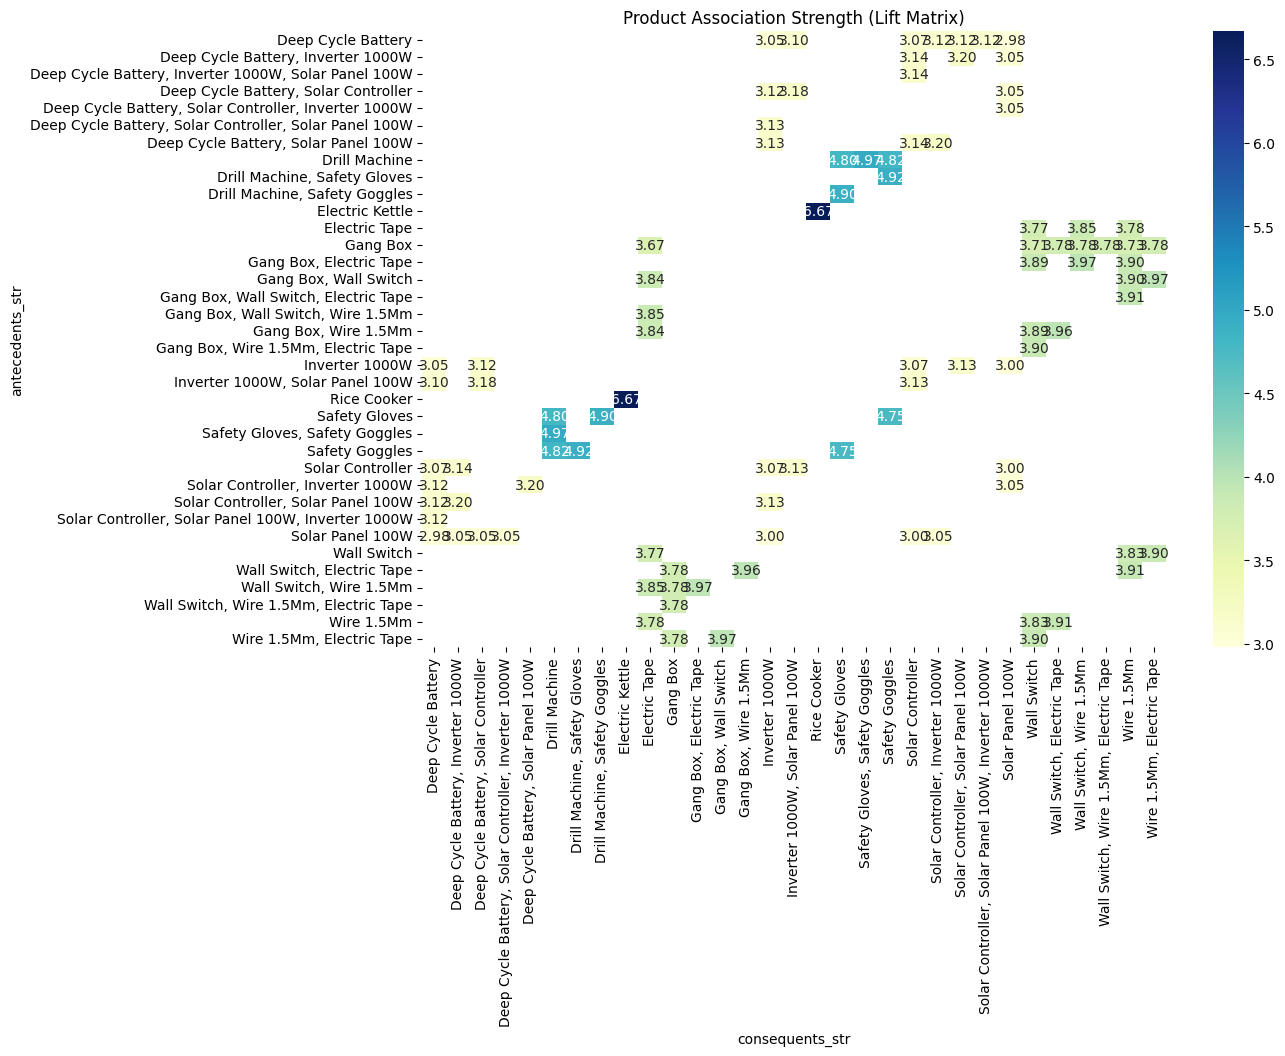

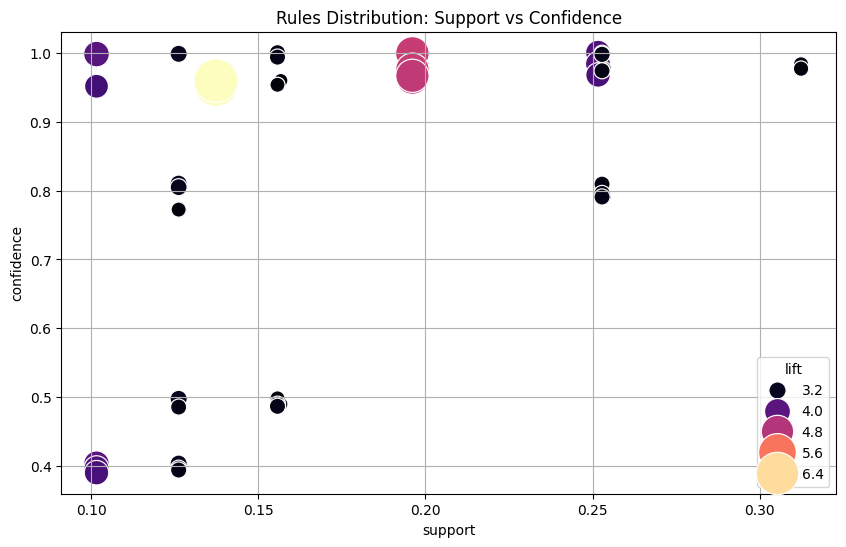

In [63]:
# --- ၆။ Visualization (Heatmap & Scatter) ---

# Heatmap ဆွဲဖို့အတွက် String Column ကို သုံးပါ (Frozenset သုံးရင် Error တက်နိုင်လို့ပါ)
filtered_rules = rules[rules['confidence'] > 0.4] # Confidence threshold 
pivot = filtered_rules.pivot_table(index='antecedents_str', columns='consequents_str', values='lift', aggfunc='max')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Product Association Strength (Lift Matrix)')
plt.show()

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules, palette="magma", sizes=(100, 1000))
plt.title('Rules Distribution: Support vs Confidence')
plt.grid(True)
plt.show()

In [64]:
# Duplicate ဖယ်ထုတ်ခြင်း (Confidence အမြင့်ဆုံးကို ဦးစားပေး)
rules_cleaned = rules.sort_values('confidence', ascending=False).drop_duplicates(subset=['antecedents_str', 'consequents_str'])


In [65]:
# --- ၇။ Database ထဲသို့ Rules များ သိမ်းဆည်းခြင်း ---


cursor = conn.cursor()
cursor.execute("TRUNCATE TABLE recommendation_rules")

for idx, row in rules_cleaned.iterrows():
    cursor.execute("""
        INSERT INTO recommendation_rules (antecedent, consequent, confidence, lift)
        VALUES (%s, %s, %s, %s)
    """, (row['antecedents_str'], row['consequents_str'], row['confidence'], row['lift']))

conn.commit()
print(f"✅ Success! {len(rules_cleaned)} rules saved to database.\n")

# --- Rules များကို ရှင်းရှင်းလင်းလင်း Visualize လုပ်ပြီး Print ထုတ်ရန် ---
print("-" * 80)
print(f"{'IF (Bought These)':<40} | {'THEN (Recommended)':<20} | {'CONFIDENCE'}")
print("-" * 80)

#  rules ကို စာသားနဲ့ ဖတ်လို့ကောင်းအောင် ပြမယ်
for idx, row in rules_cleaned.iterrows():
    # Antecedents က ပစ္စည်းတစ်ခုထက်ပိုရင် (A + B) ပုံစံပြမယ်
    if ", " in row['antecedents_str']:
        if_part = f"({row['antecedents_str']})"
    else:
        if_part = row['antecedents_str']
        
    then_part = row['consequents_str']
    conf_percent = f"{row['confidence']*100:.1f}%"
    
    print(f"{if_part:<40} | {then_part:<20} | {conf_percent}")

print("-" * 80)

✅ Success! 114 rules saved to database.

--------------------------------------------------------------------------------
IF (Bought These)                        | THEN (Recommended)   | CONFIDENCE
--------------------------------------------------------------------------------
(Wall Switch, Wire 1.5Mm)                | Electric Tape        | 100.0%
(Wire 1.5Mm, Electric Tape)              | Wall Switch          | 100.0%
(Gang Box, Wire 1.5Mm, Electric Tape)    | Wall Switch          | 100.0%
(Gang Box, Wall Switch, Electric Tape)   | Wire 1.5Mm           | 100.0%
(Gang Box, Wall Switch, Wire 1.5Mm)      | Electric Tape        | 100.0%
(Deep Cycle Battery, Solar Panel 100W)   | Inverter 1000W       | 100.0%
(Solar Controller, Solar Panel 100W)     | Inverter 1000W       | 100.0%
(Deep Cycle Battery, Solar Controller, Solar Panel 100W) | Inverter 1000W       | 100.0%
(Deep Cycle Battery, Solar Controller)   | Inverter 1000W       | 99.9%
(Wall Switch, Electric Tape)             | Wire 

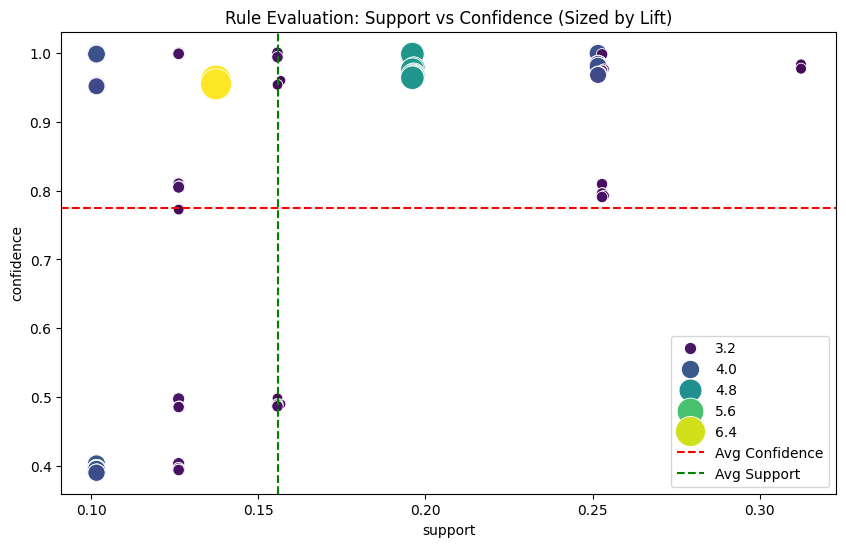

In [66]:
# Rule Quality Evaluation using Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                data=rules_cleaned, palette="viridis", sizes=(50, 500))

# Mean lines for average quality identification
plt.axhline(y=rules_cleaned['confidence'].mean(), color='r', linestyle='--', label='Avg Confidence')
plt.axvline(x=rules_cleaned['support'].mean(), color='g', linestyle='--', label='Avg Support')

plt.title('Rule Evaluation: Support vs Confidence (Sized by Lift)')
plt.legend()
plt.show()

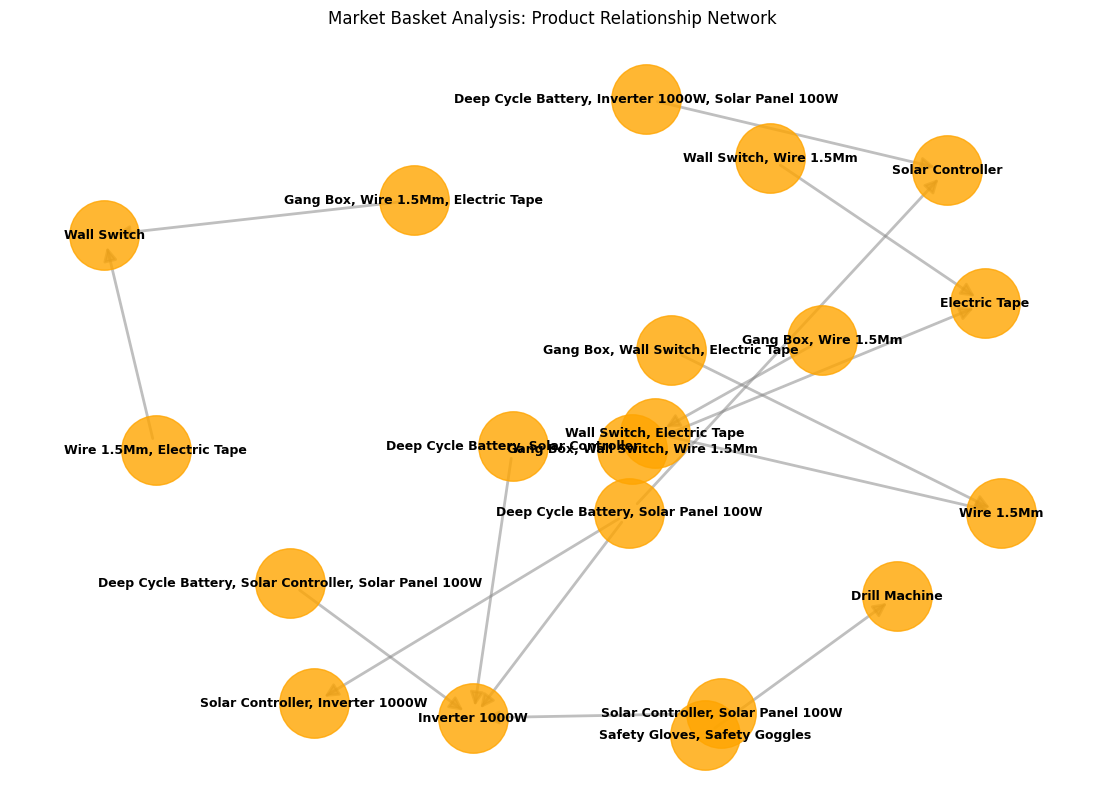

In [67]:
import networkx as nx

# Top 15 rules ကိုပဲ ယူမယ်
top_15 = rules_cleaned.head(15)

plt.figure(figsize=(14, 10))
G = nx.DiGraph()

for idx, row in top_15.iterrows():
    # Antecedent ကနေ Consequent ဆီကို မြှားဆွဲမယ်
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['confidence'])

# နေရာချထားမှုပုံစံ (Spring layout က ကြည့်လို့အကောင်းဆုံးပါ)
pos = nx.spring_layout(G, k=0.8, seed=42)

# Nodes (ပစ္စည်းနာမည်များ) ဆွဲမယ်
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="orange", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# Edges (မြှားများ) ဆွဲမယ်
nx.draw_networkx_edges(G, pos, width=2, edge_color="gray", arrowsize=20, alpha=0.5)

plt.title("Market Basket Analysis: Product Relationship Network")
plt.axis('off')
plt.show()

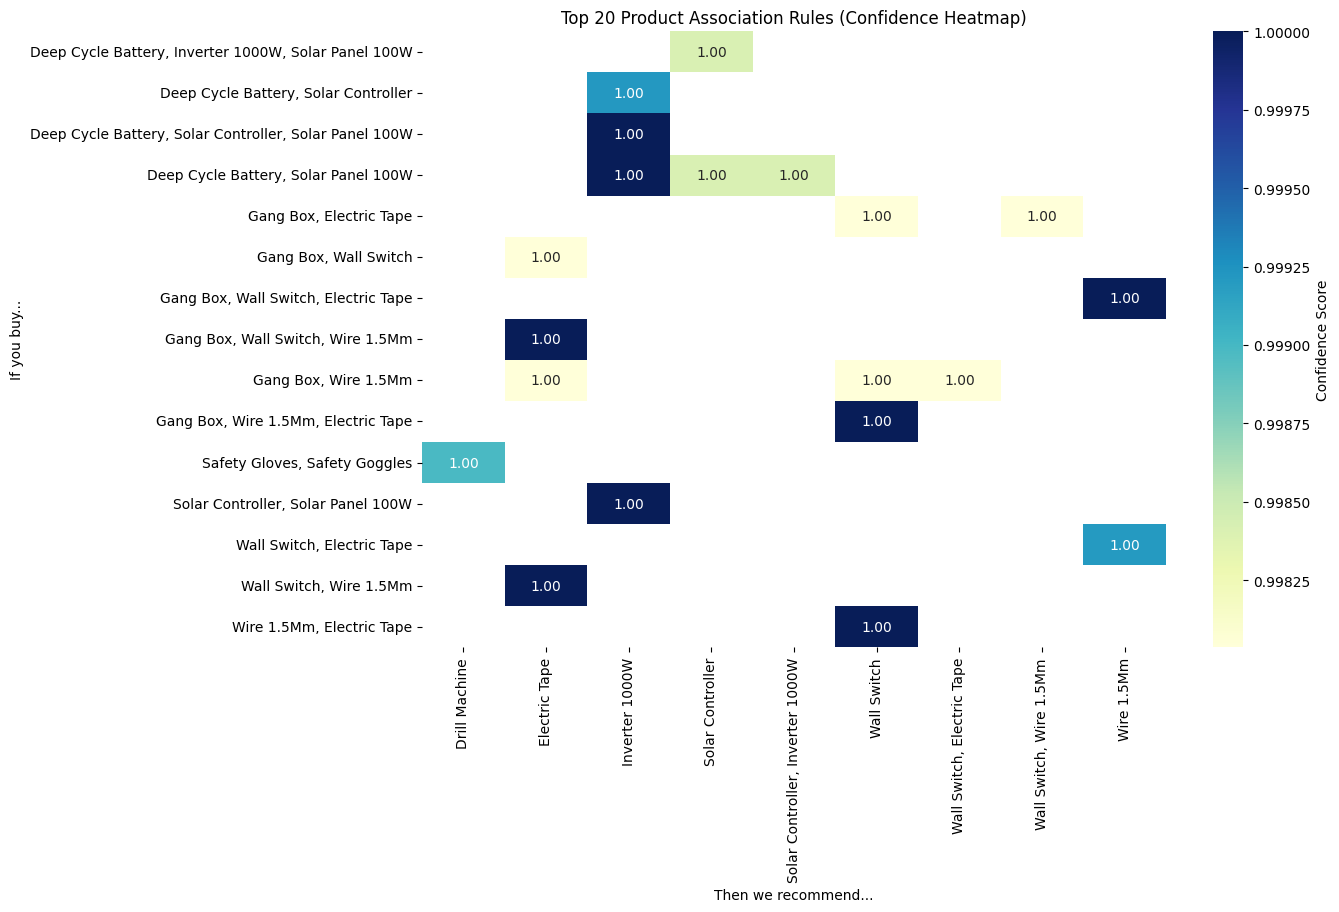

In [68]:
from pandas.plotting import parallel_coordinates

# Confidence 0.3 ထက်များတဲ့ rule တွေကိုပဲ ရွေးထုတ်မယ်
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3].head(20)

# pivot table ပြန်ဆောက်မယ်
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Confidence Score'})
plt.title('Top 20 Product Association Rules (Confidence Heatmap)')
plt.ylabel('If you buy...')
plt.xlabel('Then we recommend...')
plt.show()

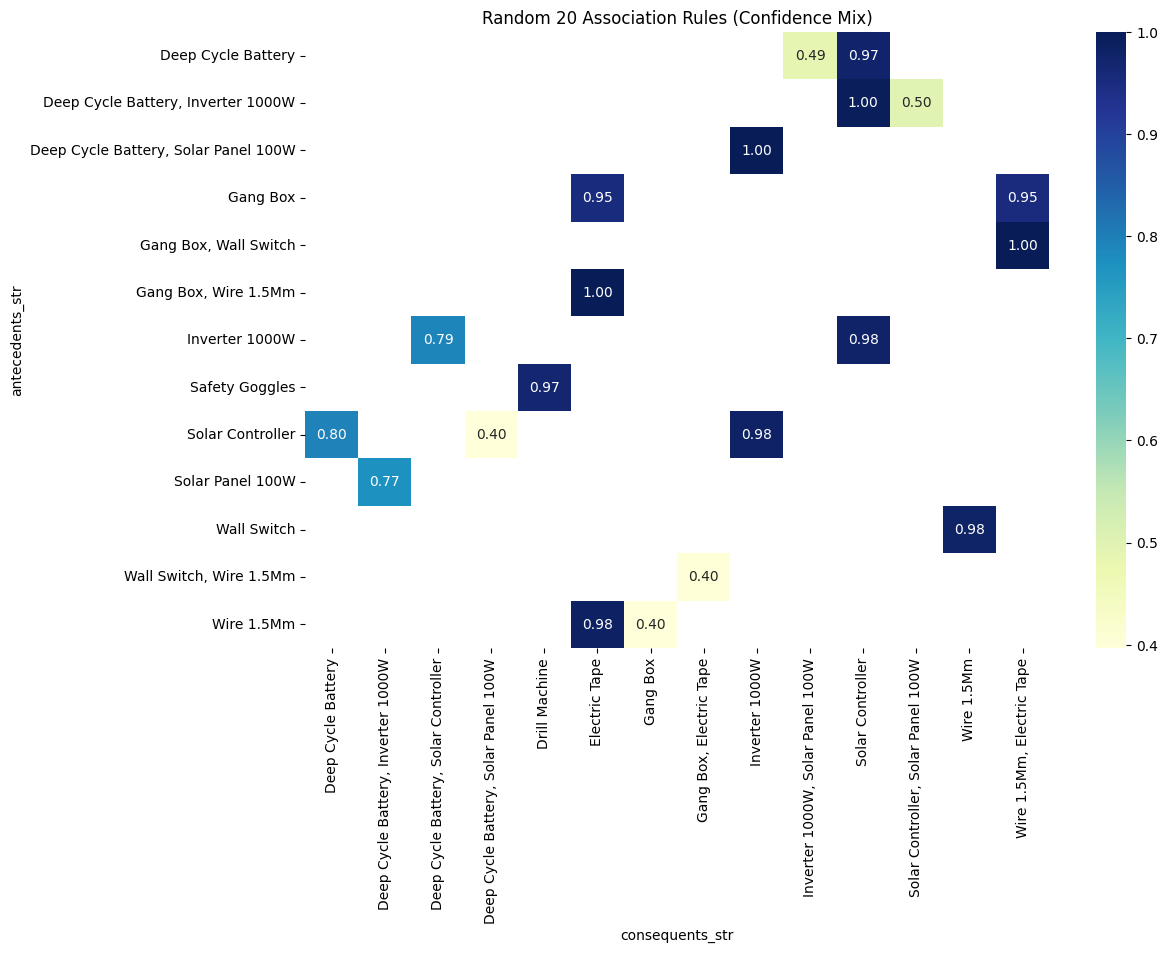

In [69]:
# Confidence 0.3 ထက်များတဲ့ rules တွေထဲကမှ ကျပန်း ၂၀ ခုကို ရွေးမယ်
# (random_state=42 ထည့်ထားရင် run တိုင်း ဒီ ၂၀ ခုပဲ ထွက်နေမှာမို့၊ 
# အမြဲပြောင်းစေချင်ရင် random_state ကို ဖြုတ်ထားလို့ရပါတယ်)
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3].sample(20)

# --- Visualize လုပ်တဲ့အပိုင်း (Heatmap ဖြင့်ပြခြင်း) ---
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Random 20 Association Rules (Confidence Mix)')
plt.show()

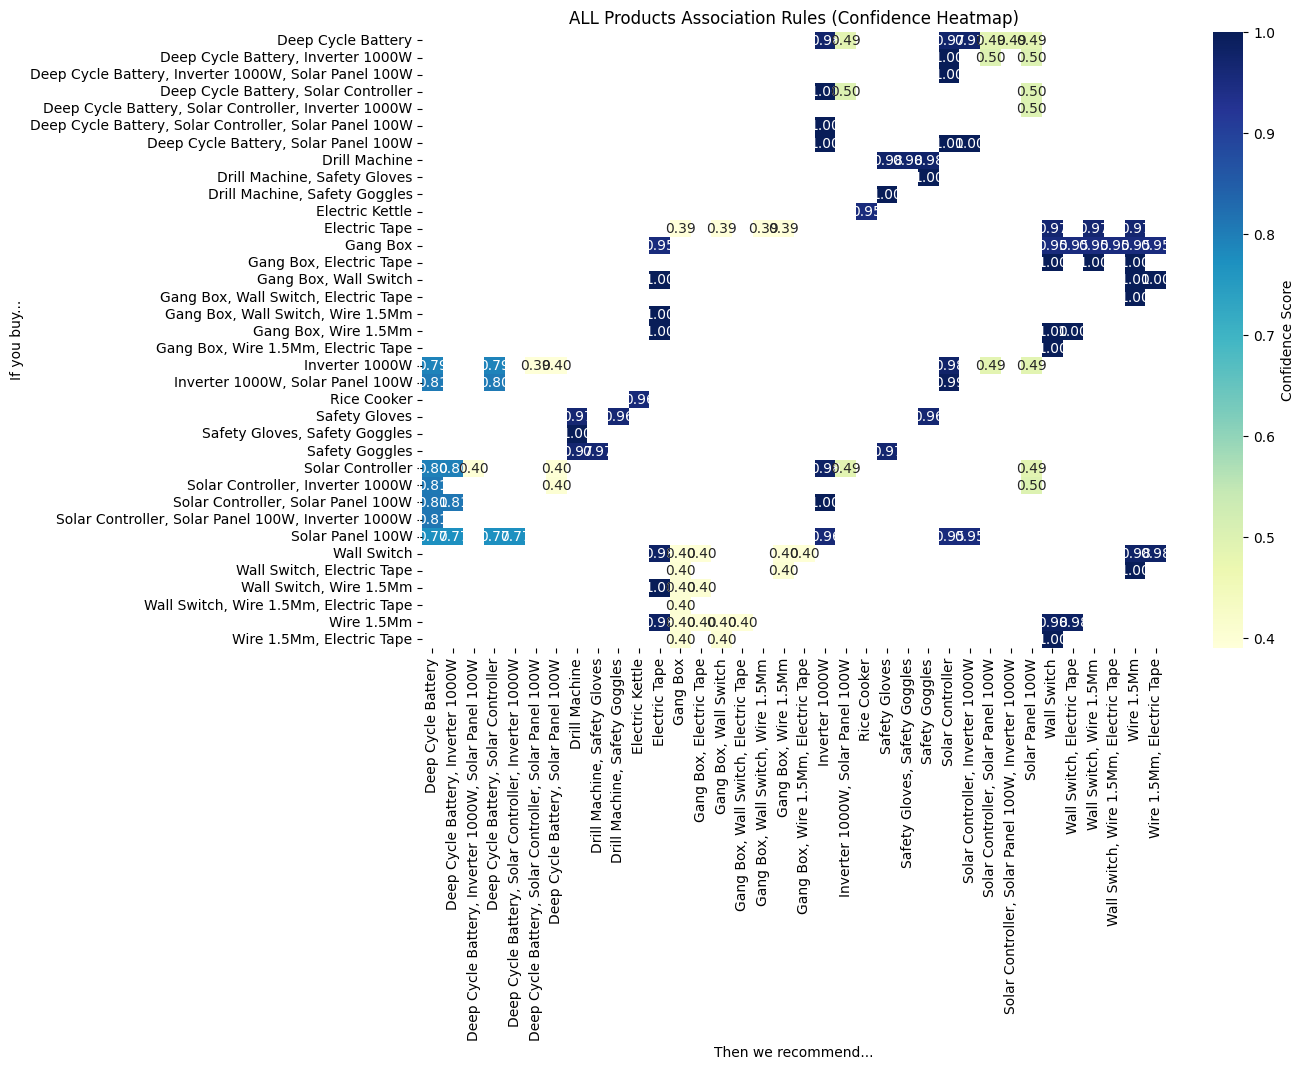

In [70]:
from pandas.plotting import parallel_coordinates

# Confidence 0.3 ထက်များတဲ့ rule တွေကိုပဲ ရွေးထုတ်မယ်
plot_rules = rules_cleaned[rules_cleaned['confidence'] > 0.3]

# pivot table ပြန်ဆောက်မယ်
pivot = plot_rules.pivot_table(index='antecedents_str', 
                               columns='consequents_str', 
                               values='confidence')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Confidence Score'})
plt.title('ALL Products Association Rules (Confidence Heatmap)')
plt.ylabel('If you buy...')
plt.xlabel('Then we recommend...')
plt.show()

In [71]:
# Forecast Sale
import numpy as np
query = """
    SELECT DATE_FORMAT(t.trans_date, '%Y-%m') as month, 
           SUM(ti.quantity * p.price) as monthly_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
    GROUP BY month ORDER BY month ASC
"""
df = pd.read_sql(query, conn)

# လအလိုက် Index နံပါတ်ပေးမယ် (ဥပမာ 0, 1, 2...)
df['month_index'] = np.arange(len(df))

In [72]:
from sklearn.linear_model import LinearRegression
# X က အချိန် (Month Index)၊ y က ရောင်းရငွေ (Revenue)
X = df[['month_index']]
y = df['monthly_revenue']

model = LinearRegression()
model.fit(X, y)

# နောက်လအတွက် ခန့်မှန်းမယ်
next_month = np.array([[len(df)]])
prediction = model.predict(next_month)

print(f"လာမည့်လအတွက် ခန့်မှန်းခြေရောင်းအား: {prediction[0]:,.0f} MMK")

လာမည့်လအတွက် ခန့်မှန်းခြေရောင်းအား: 283,579,629 MMK


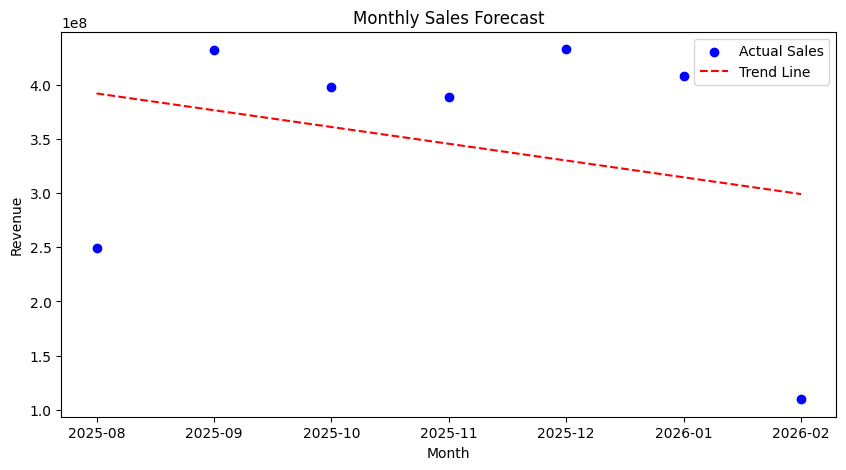

In [73]:
plt.figure(figsize=(10, 5))
plt.scatter(df['month'], df['monthly_revenue'], color='blue', label='Actual Sales')
plt.plot(df['month'], model.predict(X), color='red', linestyle='--', label='Trend Line')
plt.title('Monthly Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.show()

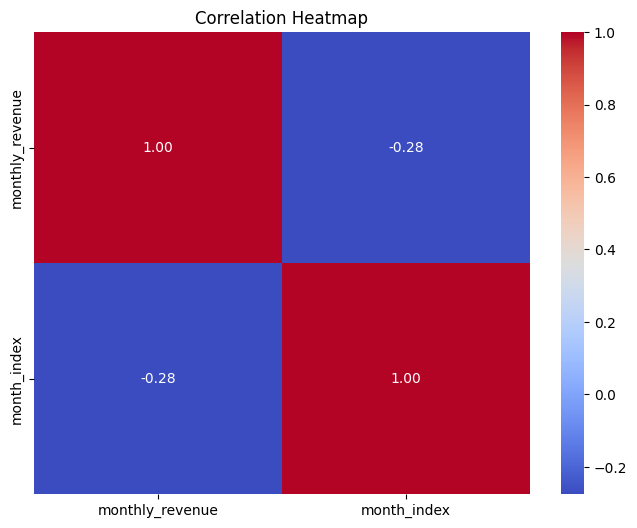

In [74]:
# numeric_only=True ထည့်မှ စာသားတွေကို ဖယ်ပြီး ကိန်းဂဏန်းတွေကိုပဲ တွက်မှာပါ
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL Query (နေ့စဉ်ရောင်းအား)
query_anomaly = """
    SELECT DATE(t.trans_date) as date, 
           SUM(ti.quantity * p.price) as daily_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
    GROUP BY date ORDER BY date ASC
"""
df_anomaly = pd.read_sql(query_anomaly, conn)
df_anomaly['date'] = pd.to_datetime(df_anomaly['date'])

In [76]:
# ၁။ ပျမ်းမျှ (Mean) နဲ့ ကွာဟချက် (Std Dev) တွက်မယ်
mean = df_anomaly['daily_revenue'].mean()
std = df_anomaly['daily_revenue'].std()

# ၂။ Z-Score တွက်ချက်ခြင်း
# Z = (Value - Mean) / Std Dev
df_anomaly['z_score'] = (df_anomaly['daily_revenue'] - mean) / std

# ၃။ Threshold သတ်မှတ်ခြင်း (ပုံမှန်အားဖြင့် 2 ထက်ကျော်ရင် Anomaly လို့ သတ်မှတ်တယ်)
threshold = 2
df_anomaly['is_anomaly'] = df_anomaly['z_score'].abs() > threshold

# Anomaly ဖြစ်တဲ့ ရက်တွေကိုပဲ ထုတ်ကြည့်မယ်
anomalies = df_anomaly[df_anomaly['is_anomaly'] == True]
print("--- Found Anomalies ---")
print(anomalies[['date', 'daily_revenue', 'z_score']])

--- Found Anomalies ---
          date  daily_revenue   z_score
0   2025-08-12        73000.0 -3.148030
35  2025-09-16     21881500.0  2.047087
44  2025-09-25     26777100.0  3.213293
50  2025-10-01     24788500.0  2.739578
69  2025-10-20     23751900.0  2.492644
76  2025-10-27      3636200.0 -2.299222
111 2025-12-01     23212900.0  2.364246
132 2025-12-22     21886200.0  2.048206
150 2026-01-09     22380400.0  2.165932


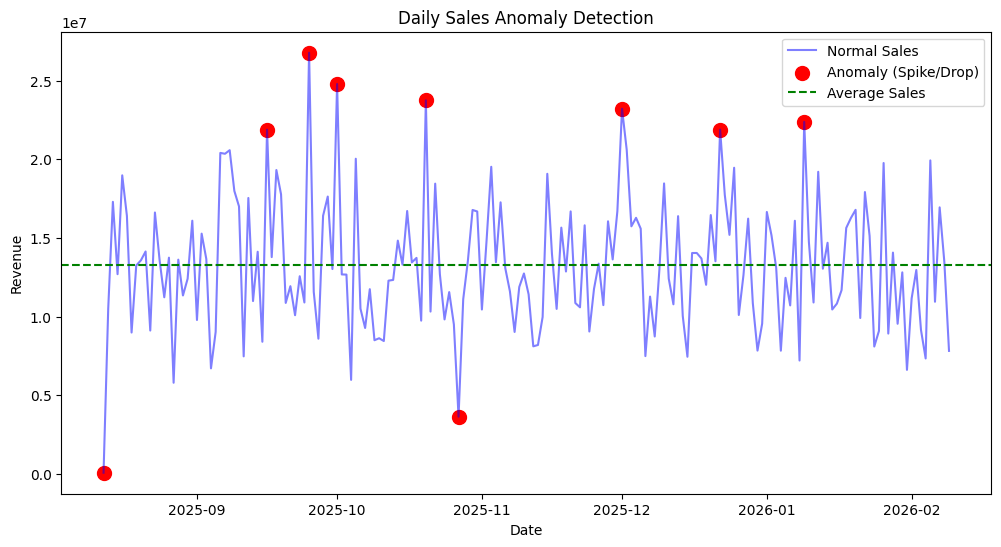

In [77]:
plt.figure(figsize=(12, 6))

# ပုံမှန် အရောင်းမျဉ်းကြောင်း
plt.plot(df_anomaly['date'], df_anomaly['daily_revenue'], color='blue', label='Normal Sales', alpha=0.5)

# Anomaly ဖြစ်တဲ့နေရာကို အနီစက်ကြီးကြီးနဲ့ပြမယ်
plt.scatter(anomalies['date'], anomalies['daily_revenue'], color='red', s=100, label='Anomaly (Spike/Drop)')

# ပျမ်းမျှမျဉ်း (Mean Line)
plt.axhline(y=mean, color='green', linestyle='--', label='Average Sales')

plt.title('Daily Sales Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

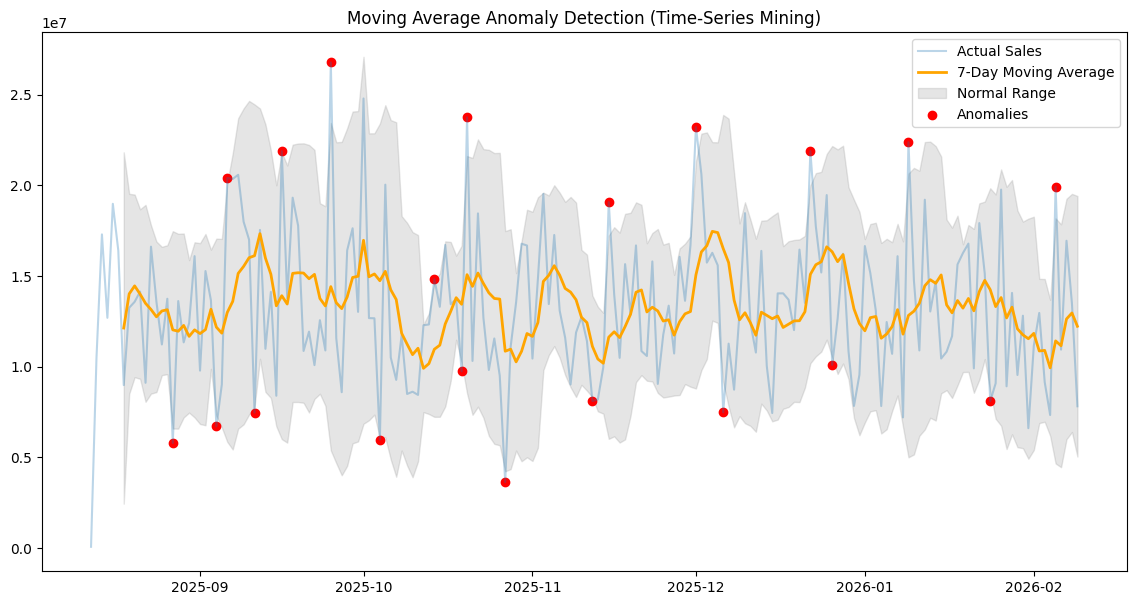

In [78]:
# ၁။ ၇ ရက်စာ Moving Average နဲ့ Standard Deviation တွက်မယ်
window = 7
df_anomaly['rolling_mean'] = df_anomaly['daily_revenue'].rolling(window=window).mean()
df_anomaly['rolling_std'] = df_anomaly['daily_revenue'].rolling(window=window).std()

# ၂။ Upper နဲ့ Lower Bound (ဘောင်) သတ်မှတ်ခြင်း
# ပျမ်းမျှရဲ့ အပေါ်/အောက် 1.5 standard deviation ကို 'ပုံမှန်' လို့ ယူဆမယ်
df_anomaly['upper_bound'] = df_anomaly['rolling_mean'] + (1.5 * df_anomaly['rolling_std'])
df_anomaly['lower_bound'] = df_anomaly['rolling_mean'] - (1.5 * df_anomaly['rolling_std'])

# ၃။ ဘောင်ကျော်တဲ့ အစက်တွေကို ရှာမယ်
df_anomaly['is_moving_anomaly'] = (df_anomaly['daily_revenue'] > df_anomaly['upper_bound']) | (df_anomaly['daily_revenue'] < df_anomaly['lower_bound'])
moving_anomalies = df_anomaly[df_anomaly['is_moving_anomaly'] == True]

# ၄။ Visualization
plt.figure(figsize=(14, 7))
plt.plot(df_anomaly['date'], df_anomaly['daily_revenue'], label='Actual Sales', alpha=0.3)
plt.plot(df_anomaly['date'], df_anomaly['rolling_mean'], label='7-Day Moving Average', color='orange', linewidth=2)

# အပေါ်ဘောင်နဲ့ အောက်ဘောင်ကို အရောင်မှိုင်းမှိုင်းလေး ခြယ်မယ် (Bollinger Bands ပုံစံ)
plt.fill_between(df_anomaly['date'], df_anomaly['lower_bound'], df_anomaly['upper_bound'], color='gray', alpha=0.2, label='Normal Range')

# Anomaly တွေကို အနီစက်ချမယ်
plt.scatter(moving_anomalies['date'], moving_anomalies['daily_revenue'], color='red', label='Anomalies')

plt.title('Moving Average Anomaly Detection (Time-Series Mining)')
plt.legend()
plt.show()

In [79]:

# Quadrant အတွက် ပစ္စည်းအလိုက် ဒေတာယူမယ်
query_quadrant = """
    SELECT p.product_name, 
           SUM(ti.quantity) as total_quantity,
           SUM(ti.quantity * p.price) as total_revenue
    FROM transactions t
    JOIN transaction_items ti ON t.trans_id = ti.trans_id
    JOIN products p ON ti.product_id = p.product_id
    WHERE t.status = 'completed'
      AND t.trans_date >= DATE_SUB(CURDATE(), INTERVAL 6 MONTH)
    GROUP BY p.product_name
"""
df_quadrant = pd.read_sql(query_quadrant, conn)


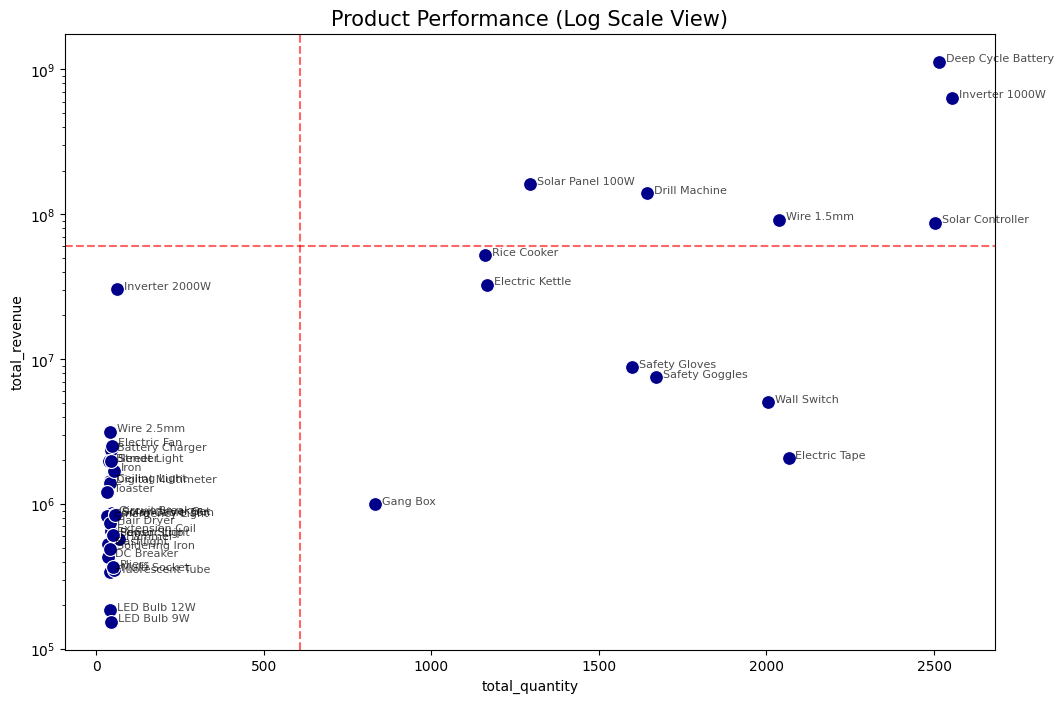

In [80]:
# ပျမ်းမျှမျဉ်းများ (သတ်မှတ်ချက်)
v_mean = df_quadrant['total_quantity'].mean()
r_mean = df_quadrant['total_revenue'].mean()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_quadrant, x='total_quantity', y='total_revenue', s=100, color='darkblue')

# Log Scale ပြောင်းရန် (ဒါက အဓိကပဲ!)
plt.yscale('log') 

# ပျမ်းမျှမျဉ်းများကိုလည်း Log scale နှင့် ကိုက်ညီအောင် ညှိရပါမယ်
plt.axhline(r_mean, color='red', linestyle='--', alpha=0.6)
plt.axvline(v_mean, color='red', linestyle='--', alpha=0.6)

# စာသားတွေ မထပ်အောင် adjust_text library သုံးရင် ပိုကောင်းပါတယ် (မရှိရင် အောက်ကအတိုင်း ရေးပါ)
for i in range(df_quadrant.shape[0]):
    plt.text(df_quadrant.total_quantity[i] + 20, 
             df_quadrant.total_revenue[i], 
             df_quadrant.product_name[i], 
             fontsize=8, alpha=0.7)

plt.title('Product Performance (Log Scale View)', fontsize=15)
plt.show()